In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
corpus = [
    "dota hero draft",
    "ancient creep camp",
    "radiant bottom lane",
    "dire middle tower",
    "carry farming jungle",
    "support ward placement",
    "roshan pit fight",
    "black king bar",
    "blink dagger initiation",
    "shadow blade escape",
    "aghanim scepter upgrade",
    "butterfly damage item",
    "manta style illusion",
    "divine rapier damage",
    "creep wave control",
    "mid lane rotation",
    "offlane pressure strategy",
    "smoke gank timing",
    "team fight coordination",
    "base defense glyph",
]

In [3]:
#1. tokenization
corpus = [sent.split(" ") for sent in corpus]
corpus

[['dota', 'hero', 'draft'],
 ['ancient', 'creep', 'camp'],
 ['radiant', 'bottom', 'lane'],
 ['dire', 'middle', 'tower'],
 ['carry', 'farming', 'jungle'],
 ['support', 'ward', 'placement'],
 ['roshan', 'pit', 'fight'],
 ['black', 'king', 'bar'],
 ['blink', 'dagger', 'initiation'],
 ['shadow', 'blade', 'escape'],
 ['aghanim', 'scepter', 'upgrade'],
 ['butterfly', 'damage', 'item'],
 ['manta', 'style', 'illusion'],
 ['divine', 'rapier', 'damage'],
 ['creep', 'wave', 'control'],
 ['mid', 'lane', 'rotation'],
 ['offlane', 'pressure', 'strategy'],
 ['smoke', 'gank', 'timing'],
 ['team', 'fight', 'coordination'],
 ['base', 'defense', 'glyph']]

In [4]:
#2. numeralization
#find unique words
flatten = lambda l: [item for sublist in l for item in sublist]
#assign unique integer
vocabs = list(set(flatten(corpus)))
vocabs

['upgrade',
 'roshan',
 'rapier',
 'blade',
 'defense',
 'mid',
 'damage',
 'creep',
 'scepter',
 'support',
 'dire',
 'initiation',
 'divine',
 'manta',
 'timing',
 'strategy',
 'base',
 'escape',
 'hero',
 'dagger',
 'bottom',
 'farming',
 'king',
 'coordination',
 'illusion',
 'ward',
 'radiant',
 'wave',
 'dota',
 'camp',
 'black',
 'offlane',
 'jungle',
 'draft',
 'placement',
 'control',
 'pressure',
 'smoke',
 'rotation',
 'lane',
 'middle',
 'item',
 'gank',
 'ancient',
 'tower',
 'aghanim',
 'team',
 'shadow',
 'glyph',
 'bar',
 'style',
 'pit',
 'carry',
 'blink',
 'butterfly',
 'fight']

In [5]:
#create handy mapping between integer and word
word2index = {v:idx for idx, v in enumerate(vocabs)}
word2index["radiant"]

26

In [6]:
vocabs.append("<UNK>")
word2index["<UNK>"] = 56
word2index["<UNK>"]

56

In [7]:
index2word = {v: k for k, v in word2index.items()}
index2word

{0: 'upgrade',
 1: 'roshan',
 2: 'rapier',
 3: 'blade',
 4: 'defense',
 5: 'mid',
 6: 'damage',
 7: 'creep',
 8: 'scepter',
 9: 'support',
 10: 'dire',
 11: 'initiation',
 12: 'divine',
 13: 'manta',
 14: 'timing',
 15: 'strategy',
 16: 'base',
 17: 'escape',
 18: 'hero',
 19: 'dagger',
 20: 'bottom',
 21: 'farming',
 22: 'king',
 23: 'coordination',
 24: 'illusion',
 25: 'ward',
 26: 'radiant',
 27: 'wave',
 28: 'dota',
 29: 'camp',
 30: 'black',
 31: 'offlane',
 32: 'jungle',
 33: 'draft',
 34: 'placement',
 35: 'control',
 36: 'pressure',
 37: 'smoke',
 38: 'rotation',
 39: 'lane',
 40: 'middle',
 41: 'item',
 42: 'gank',
 43: 'ancient',
 44: 'tower',
 45: 'aghanim',
 46: 'team',
 47: 'shadow',
 48: 'glyph',
 49: 'bar',
 50: 'style',
 51: 'pit',
 52: 'carry',
 53: 'blink',
 54: 'butterfly',
 55: 'fight',
 56: '<UNK>'}

In [8]:
#create pairs of center word, and outside word

#loop each corpus
    #loop each document
        # look from the 2nd word until second last word (window = 1)
            # center word
            # outside words = 2 words
            # for each of these two outside words, we gonna append to a list
                # center, outside1; center, outside2
skipgrams = []
for doc in corpus:
    for i in range(1, len(doc) - 1):
        center = word2index[doc[i]]
        outside = (word2index[doc[i - 1]], word2index[doc[i + 1]])
        for each_out in outside:
            skipgrams.append([center, each_out])
skipgrams

[[18, 28],
 [18, 33],
 [7, 43],
 [7, 29],
 [20, 26],
 [20, 39],
 [40, 10],
 [40, 44],
 [21, 52],
 [21, 32],
 [25, 9],
 [25, 34],
 [51, 1],
 [51, 55],
 [22, 30],
 [22, 49],
 [19, 53],
 [19, 11],
 [3, 47],
 [3, 17],
 [8, 45],
 [8, 0],
 [6, 54],
 [6, 41],
 [50, 13],
 [50, 24],
 [2, 12],
 [2, 6],
 [27, 7],
 [27, 35],
 [39, 5],
 [39, 38],
 [36, 31],
 [36, 15],
 [42, 37],
 [42, 14],
 [55, 46],
 [55, 23],
 [4, 16],
 [4, 48]]

In [9]:
def random_batch(batch_size, corpus):
    skipgrams = []
    for doc in corpus:
        for i in range(1, len(doc) - 1):
            center = word2index[doc[i]]
            outside = (word2index[doc[i - 1]], word2index[doc[i + 1]])
            for each_out in outside:
                skipgrams.append([center, each_out])

    random_indexes = np.random.choice(range(len(skipgrams)), batch_size, replace=False)
    inputs, labels = [], []
    for index in random_indexes:
        inputs.append([skipgrams[index][0]])
        labels.append([skipgrams[index][1]])
    return np.array(inputs), np.array(labels)

x, y = random_batch(3, corpus)
x.shape
y.shape
x, y

(array([[40],
        [42],
        [19]]),
 array([[44],
        [37],
        [53]]))

In [10]:
voc_size = 57
emb_size = 57
embedding = nn.Embedding(voc_size, emb_size)

a = torch.LongTensor([56])
embedding(a)

tensor([[ 1.2139, -0.4916, -0.0290,  0.3844,  0.2132,  0.5768,  0.7471, -0.9560,
         -0.1954, -0.4825,  0.5458, -0.1206, -0.4437,  0.0551, -1.0829,  1.0254,
         -3.0004,  0.3228,  0.3993,  0.6747,  0.6538,  0.4042, -1.3422,  0.0849,
         -0.8465, -0.0132, -1.1760, -2.0744, -0.5791, -0.8930, -0.3625, -0.5040,
          0.1408,  0.6871,  1.1242, -0.9550,  0.8037,  0.0117, -2.5189,  0.9229,
          1.3770, -0.0738,  0.6562,  0.2986, -0.1224, -0.8677, -0.8875,  1.0302,
          0.4766,  1.8163,  0.5919,  0.0848,  0.4527,  1.1061,  0.2821,  1.7587,
          1.5561]], grad_fn=<EmbeddingBackward0>)

In [11]:
# model

class Skipgram(nn.Module):
    def __init__(self, voc_size, emb_size):
        super(Skipgram, self).__init__()
        self.embeding_center = nn.Embedding(voc_size, emb_size)
        self.embeding_outside = nn.Embedding(voc_size, emb_size)

    def forward(self, center, outside, all_vocabs):
        center_embedding = self.embeding_center(center)
        outside_embedding = self.embeding_outside(outside)
        all_vocabs_embeding = self.embeding_outside(all_vocabs)

        top_term = torch.exp(outside_embedding.bmm(center_embedding.transpose(1, 2)).squeeze(2))
        #(batch_size, 1, emb_size) @ (batch_size, emb_size, 1) = (batch_size, 1, 1) -> (batch_size, 1)

        lower_term = all_vocabs_embeding.bmm(center_embedding.transpose(1, 2)).squeeze(2)
        #(batch_size, voc_size, emb_size) @ (batch_size, emb_size, 1) = (batch_size, voc_size, 1) -> (batch_size, voc_size)

        lower_term_sum = torch.sum(torch.exp(lower_term), 1, keepdim=True) # (batch_size, 1)

        loss = -torch.mean(torch.log(top_term / lower_term_sum))

        return loss

In [12]:
batch_size = 3

def prepare_sequence(seq, word2index):
    idxs = list(map(lambda w: word2index[w] if word2index.get(w) is not None else word2index["<UNK>"], seq))
    return torch.LongTensor(idxs)

In [13]:
all_vocabs = prepare_sequence(list(vocabs), word2index).expand(batch_size, voc_size)
all_vocabs

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56]])

In [14]:
model = Skipgram(voc_size, 2)
model

Skipgram(
  (embeding_center): Embedding(57, 2)
  (embeding_outside): Embedding(57, 2)
)

In [15]:
input_tensor = torch.LongTensor(x)
label_tensor = torch.LongTensor(y)

In [16]:
loss = model(input_tensor, label_tensor, all_vocabs)
loss

tensor(5.4141, grad_fn=<NegBackward0>)

In [17]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [30]:
num_epochs = 10000

for epoch in range(num_epochs):
    # get batch
    input_batch, label_batch = random_batch(batch_size, corpus)
    input_tensor = torch.LongTensor(input_batch)
    label_tensor = torch.LongTensor(label_batch)
    # predict
    loss = model(input_tensor, label_tensor, all_vocabs)
    # backpropogate
    optimizer.zero_grad()
    loss.backward()
    # update alpha
    optimizer.step()
    # print the loss
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss: 2.6f}")

Epoch 100 | Loss:  3.504606
Epoch 200 | Loss:  3.353706
Epoch 300 | Loss:  2.447642
Epoch 400 | Loss:  3.006177
Epoch 500 | Loss:  3.084925
Epoch 600 | Loss:  2.992215
Epoch 700 | Loss:  2.633968
Epoch 800 | Loss:  2.511684
Epoch 900 | Loss:  3.099340
Epoch 1000 | Loss:  2.652877
Epoch 1100 | Loss:  3.385733
Epoch 1200 | Loss:  2.103827
Epoch 1300 | Loss:  2.434048
Epoch 1400 | Loss:  2.149153
Epoch 1500 | Loss:  3.047448
Epoch 1600 | Loss:  3.201000
Epoch 1700 | Loss:  2.354099
Epoch 1800 | Loss:  3.538972
Epoch 1900 | Loss:  2.920532
Epoch 2000 | Loss:  2.731737
Epoch 2100 | Loss:  2.412186
Epoch 2200 | Loss:  2.989403
Epoch 2300 | Loss:  1.857482
Epoch 2400 | Loss:  2.508327
Epoch 2500 | Loss:  2.657862
Epoch 2600 | Loss:  2.945877
Epoch 2700 | Loss:  2.408463
Epoch 2800 | Loss:  2.302535
Epoch 2900 | Loss:  2.896876
Epoch 3000 | Loss:  2.514349
Epoch 3100 | Loss:  3.470487
Epoch 3200 | Loss:  3.102075
Epoch 3300 | Loss:  1.786489
Epoch 3400 | Loss:  2.739533
Epoch 3500 | Loss:  2.6

In [26]:
# plot the embeddings

vocabs
item = torch.LongTensor([word2index["item"]])
item_embed_center = model.embeding_center(item)
item_embed_outside = model.embeding_outside(item)
item_embed = (item_embed_center + item_embed_outside) / 2
vocabs

['upgrade',
 'roshan',
 'rapier',
 'blade',
 'defense',
 'mid',
 'damage',
 'creep',
 'scepter',
 'support',
 'dire',
 'initiation',
 'divine',
 'manta',
 'timing',
 'strategy',
 'base',
 'escape',
 'hero',
 'dagger',
 'bottom',
 'farming',
 'king',
 'coordination',
 'illusion',
 'ward',
 'radiant',
 'wave',
 'dota',
 'camp',
 'black',
 'offlane',
 'jungle',
 'draft',
 'placement',
 'control',
 'pressure',
 'smoke',
 'rotation',
 'lane',
 'middle',
 'item',
 'gank',
 'ancient',
 'tower',
 'aghanim',
 'team',
 'shadow',
 'glyph',
 'bar',
 'style',
 'pit',
 'carry',
 'blink',
 'butterfly',
 'fight',
 '<UNK>']

In [27]:
def get_embed(word):
    try:
        idx = torch.LongTensor([word2index[word]])
    except:
        idx = torch.LongTensor([word2index["<UNK>"]])
    embed_center = model.embeding_center(idx)
    embed_outside = model.embeding_outside(idx)
    final_embed = (embed_center + embed_outside) / 2
    return final_embed[0][0].item(), final_embed[0][1].item()

In [28]:
get_embed('blade')[0]

-0.5015420913696289

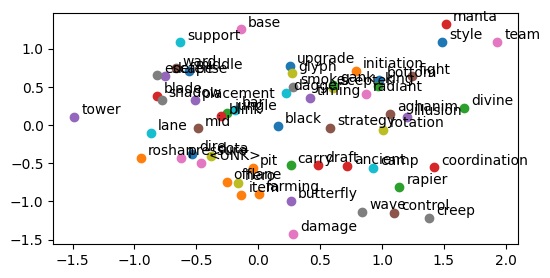

In [31]:
plt.figure(figsize=(6, 3))
for i, word in enumerate(vocabs):
    x, y = get_embed(word)
    plt.scatter(x, y)
    plt.annotate(word, xy=(x, y), xytext=(5, 2), textcoords="offset points")

In [36]:
wave = get_embed("manta")
control = get_embed("tower")

np.array(wave) @ np.array(control)

np.float64(-2.1129568550662157)